- 41,423 labelled planets - These are the planets from which we will create the train / validation / calibration / test splits.
- 685 external challenge planets - The unseen challenge objects for which we do not have the seven target values.

# **1. Target exploration**

Track A predicts seven simulator parameters:
planetary radius, atmospheric
temperature and five molecular log-abundances. Their order is defined
explicitly because every later target array, model output and inverse
transformation must use the same order.

This section verifies that all required targets exist and contain finite numeric
values. It then summarises their distributions and numerical scales. These are
source-data EDA statistics only(!), they will not be used as fitted preprocessing
parameters.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TARGET_PATH = (
    PROJECT_ROOT
    / "FullDataset"
    / "TrainingData"
    / "Ground Truth Package"
    / "FM_Parameter_Table.csv"
)

if not TARGET_PATH.is_file():
    raise FileNotFoundError(
        f"Simulator target table not found: {TARGET_PATH}"
    )

targets = pd.read_csv(TARGET_PATH)

print("Target file:", TARGET_PATH)
print("Raw target-table shape:", targets.shape)
print("Raw columns:", targets.columns.tolist())

Target file: /home/ajf23/Documents/Coding new/University stuff/ADC2023/ADC2023-conformal-prediction/FullDataset/TrainingData/Ground Truth Package/FM_Parameter_Table.csv
Raw target-table shape: (41423, 9)
Raw columns: ['Unnamed: 0', 'planet_ID', 'planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']


## Define and validate targets

In [3]:
# Fixes target order
TARGET_COLUMNS = [
    "planet_radius",
    "planet_temp",
    "log_H2O",
    "log_CO2",
    "log_CO",
    "log_CH4",
    "log_NH3",
]

missing_target_columns = [column for column in TARGET_COLUMNS
                          if column not in targets.columns]

if missing_target_columns:
    raise ValueError(
        "The simulator target table is missing required columns:" f"{missing_target_columns}"
    )

# Creates a target-only DF shape (41423, 7)
target_only = targets.loc[:, TARGET_COLUMNS].copy()

# Verify every selected value is numeric
try:
    target_only = target_only.apply(pd.to_numeric, errors="raise")

except (TypeError, ValueError) as error:
    raise ValueError("One or more target columns have non-numeric values.") from error

target_values = target_only.to_numpy(dtype=np.float64)
finite_mask = np.isfinite(target_values)

if not finite_mask.all():
    non_finite_counts = {column: int((~finite_mask[:, index]).sum())
                         for index, column in enumerate(TARGET_COLUMNS)
                         if (~finite_mask[:, index]).any()
                         }
    raise ValueError(
        "Non finite target values were detected: "
        f"{non_finite_counts}"
    )

print("Target DataFrame shape:", target_only.shape)
print("Target columns:", target_only.columns.tolist())
print("All target values are numeric and finite.")

Target DataFrame shape: (41423, 7)
Target columns: ['planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
All target values are numeric and finite.


## Summary stats and ranges

The targets have numerical scales.

For example, atmospheric temperature is measured on a much larger numerical
scale than planetary radius or a logarithmic abundance. If these targets were
used directly in a multi-output loss, the larger-scale targets could dominate.

The data pipeline will therefore standardise each target separately.
However, its means and standard deviations must be fitted using the future
training data only. Using statistics from validation, calibration or test
targets would leak information from those into model training.

In [4]:
summary_columns = [
    "count",
    "mean",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
]


# Transposing (.T) places one target on each row, which makes comparisons easier.
target_summary = (target_only.describe(percentiles=[0.25, 0.50, 0.75]).T.loc[:, summary_columns]
                  .rename(columns={
                      "min": "minimum",
                      "25%": "25th_percentile",
                      "50%": "median",
                      "75%": "75th_percentile",
                      "max": "maximum"
                  }))

target_ranges = pd.DataFrame({"minimum": target_only.min(),
                              "maximum": target_only.max()})

target_ranges["range"] = (target_ranges["maximum"] -target_ranges["minimum"])

print("Target summary:")
display(target_summary)

print("\nTarget ranges:")
display(target_ranges)

Target summary:


,count,mean,std,minimum,25th_percentile,median,75th_percentile,maximum
planet_radius,41423.0,0.655128,0.453444,0.075000,0.247160,0.491891,1.037999,2.429861
planet_temp,41423.0,1004.971922,401.278224,101.021245,699.502902,912.143137,1213.682913,4965.288165
log_H2O,41423.0,-5.982997,1.733389,-8.999856,-7.482630,-5.968308,-4.482412,-3.000497
log_CO2,41423.0,-6.522149,1.437302,-8.999932,-7.766406,-6.524401,-5.291455,-4.000009
log_CO,41423.0,-4.491494,0.869522,-5.999984,-5.241152,-4.486111,-3.734558,-3.000010
log_CH4,41423.0,-5.997146,1.731234,-8.999856,-7.489864,-6.005781,-4.494879,-3.000333
log_NH3,41423.0,-6.494065,1.456278,-8.999985,-7.767215,-6.489616,-5.249536,-3.004636



Target ranges:


,minimum,maximum,range
planet_radius,0.075000,2.429861,2.354861
planet_temp,101.021245,4965.288165,4864.266920
log_H2O,-8.999856,-3.000497,5.999358
log_CO2,-8.999932,-4.000009,4.999923
log_CO,-5.999984,-3.000010,2.999973
log_CH4,-8.999856,-3.000333,5.999524
log_NH3,-8.999985,-3.004636,5.995349


### Target distributions

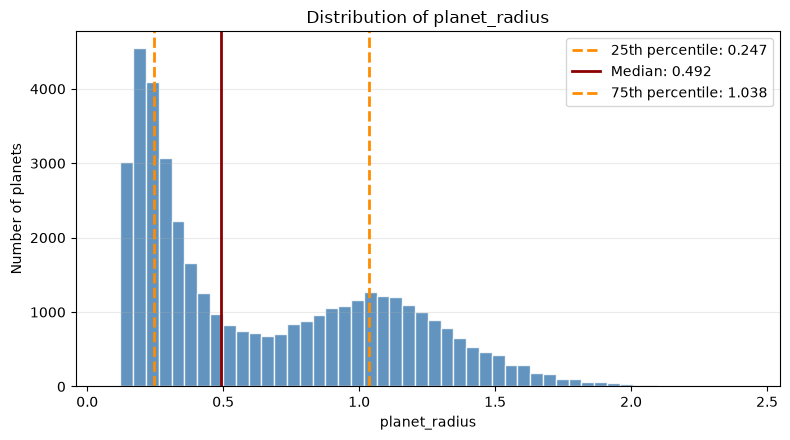

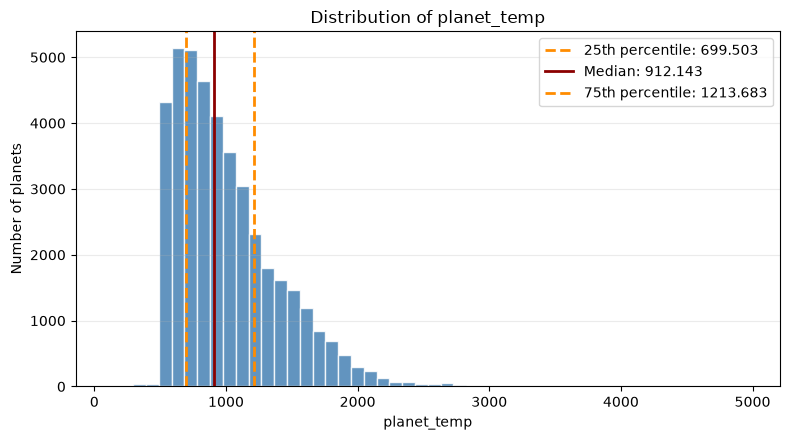

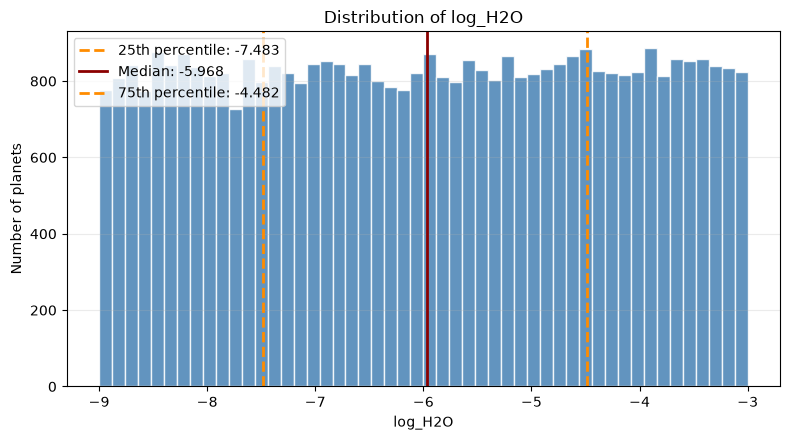

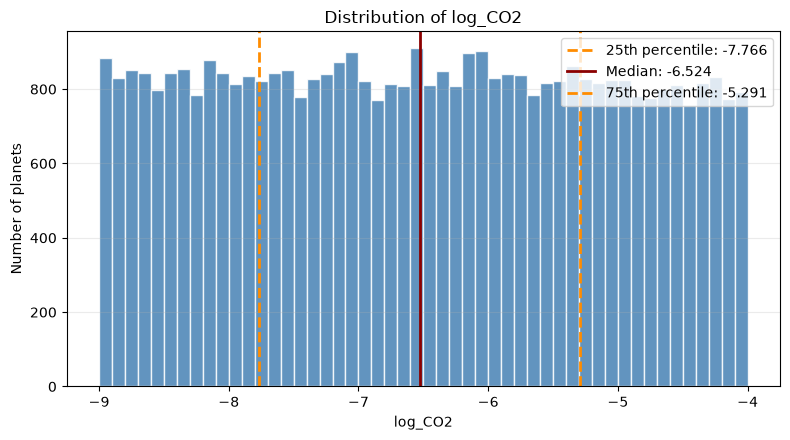

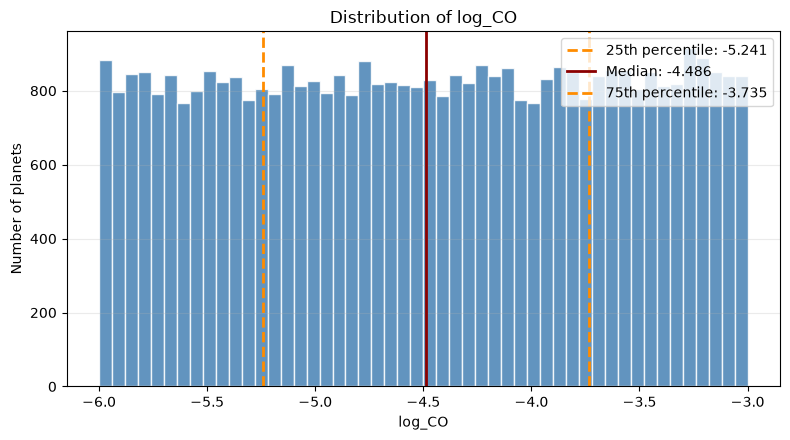

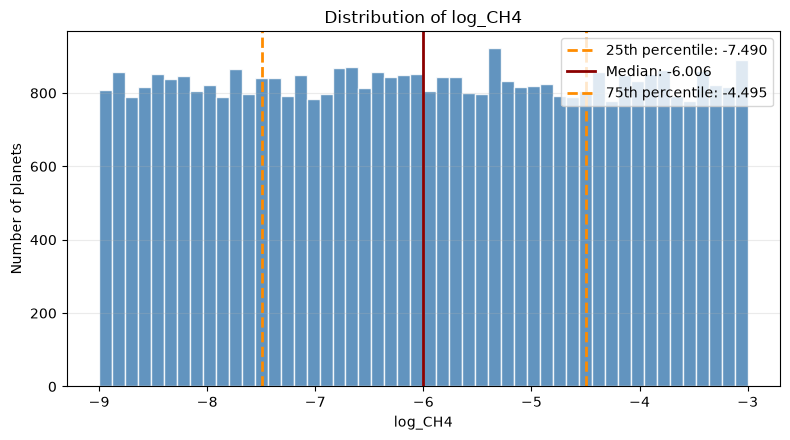

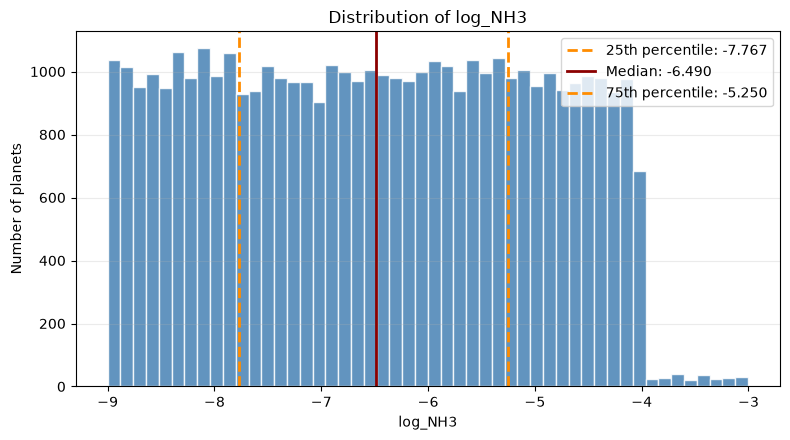

In [5]:
import matplotlib.pyplot as plt

HISTOGRAM_BINS = 50

for target_name in TARGET_COLUMNS:
    target_values = target_only[target_name]

    q25 = target_values.quantile(0.25)
    median = target_values.quantile(0.50)
    q75 = target_values.quantile(0.75)

    fig, ax = plt.subplots(figsize=(8,4.5))

    ax.hist(target_values, bins=HISTOGRAM_BINS, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(q25, color="darkorange", linestyle="--",linewidth=2, label=f"25th percentile: {q25:.3f}")
    ax.axvline(median, color="darkred", linestyle="-", linewidth=2, label=f"Median: {median:.3f}")
    ax.axvline(q75, color="darkorange", linestyle="--", linewidth=2, label=f"75th percentile: {q75:.3f}")

    ax.set_title(f"Distribution of {target_name}")
    ax.set_xlabel(f"{target_name}")
    ax.set_ylabel("Number of planets")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Analysis of plots

`planet_radius`:
- **Multimodal**
- strong cluster of smaller planets around 0.2-0.4.
- second cluster around 0.9-1.3
- thin right tail

Simulated dataset contains more than one planet population?

`planet_temp`:
- most data is in range of 500 - 1500.
- right-skewed.

#### **Molecular abundance targets**

- `log_H20`: unifrom range -9 to -3
- `log_CO2`: uniform range -9 to -4
- `log_CO`: uniform range -6 to -3
- `log_CH4`: uniform range -9 to -3
- `log_NH3`: uniform -9 to -4, sharp drop density -4 to -3.

Marginal coverage might **not** be enough. 90% coverage across all planets could be achieved but perform poorly for very hot planets, large-radius planets, region > -4 for `log_NH3`.

## **1.2. Observed target-distribution features**

The target histograms suggest several points that need to be quantified before
drawing conclusions:

- `planet_radius` appears potentially multimodal;
- `planet_temp` has a strong right-skewed tail;
- `log_H2O`, `log_CO2`, `log_CO` and `log_CH4` appear approximately uniform
  within bounded ranges;
- `log_NH3` shows a sharp reduction in density above approximately `-4`.

These are descriptive observations from the data, **not** physical explanations.
They may reflect some simulator sampling rules/processes, planet population structure or a byproduct of the construction of the dataset. We need to perform some checks to establish
the size and location of these regions.

##### **Target quantiles**

In [6]:
QUANTILE_LEVELS = [
    0.000,
    0.010,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.990,
    0.995,
    1.000,
]

QUANTILE_LABELS = [
    "0%",
    "1%",
    "5%",
    "25%",
    "50%",
    "75%",
    "95%",
    "99%",
    "99.5%",
    "100%",
]

# Keep a copy/snapshot so we can confirm that the EDA does not modify targets
target_snapshot = target_only.copy(deep=True) # Do NOT call a variable 'copy', risks naming issues
target_quantiles = target_only.quantile(QUANTILE_LEVELS).T
target_quantiles.columns = QUANTILE_LABELS
print("Target quantiles:")
display(target_quantiles)

Target quantiles:


,0%,1%,5%,25%,50%,75%,95%,99%,99.5%,100%
planet_radius,0.075000,0.139437,0.159058,0.247160,0.491891,1.037999,1.460436,1.738455,1.852681,2.429861
planet_temp,101.021245,506.832139,542.267737,699.502902,912.143137,1213.682913,1770.516832,2189.800687,2459.179739,4965.288165
log_H2O,-8.999856,-8.933326,-8.691685,-7.482630,-5.968308,-4.482412,-3.299812,-3.061809,-3.031738,-3.000497
log_CO2,-8.999932,-8.953568,-8.758136,-7.766406,-6.524401,-5.291455,-4.259023,-4.052621,-4.026313,-4.000009
log_CO,-5.999984,-5.971193,-5.853478,-5.241152,-4.486111,-3.734558,-3.148324,-3.029170,-3.014652,-3.000010
log_CH4,-8.999856,-8.937492,-8.699810,-7.489864,-6.005781,-4.494879,-3.292086,-3.055172,-3.028334,-3.000333
log_NH3,-8.999985,-8.951560,-8.757598,-7.767215,-6.489616,-5.249536,-4.226713,-4.023059,-3.859367,-3.004636


#### **Temp tail counts**

In [7]:
temperature = target_only["planet_temp"]
total_planets = len(target_only)
temperature_thresholds = [2000, 3000, 4000]

temperature_tail_rows = []

for threshold in temperature_thresholds:
    count = int((temperature > threshold).sum())
    percentage = count / total_planets * 100

    temperature_tail_rows.append({"condition": f"planet_temp >  {threshold}",
                                  "count": count,
                                  "percentage": percentage})

temperature_tail_summary = pd.DataFrame(temperature_tail_rows)
print("Planets in the high temperature tail")
display(temperature_tail_summary)

Planets in the high temperature tail


,condition,count,percentage
0,planet_temp > 2000,867,2.093040
1,planet_temp > 3000,57,0.137605
2,planet_temp > 4000,14,0.033798


#### **Ammonia/NH3 (log) counts**

In [8]:
ammonia = target_only["log_NH3"]

ammonia_region_summary = pd.DataFrame(
    [
        {   "condition": "log_NH3 <= -4",
            "count": int((ammonia <= -4).sum())
         },
         {
            "condition": "log_NH3 > -4",
            "count": int((ammonia > -4).sum()) 
         }
    ]
)

ammonia_region_summary["percentage"] = (ammonia_region_summary["count"] / total_planets *100)
print("Counts of planets on either side of the boundary for log_NH3 = -4")
display(ammonia_region_summary)

Counts of planets on either side of the boundary for log_NH3 = -4


,condition,count,percentage
0,log_NH3 <= -4,41184,99.423026
1,log_NH3 > -4,239,0.576974


#### **Fixed-width bins for NH3**

In [9]:
AMMONIA_BIN_WIDTH = 0.25

# np.floor and np.ceil align the bin boundaries to multiples of 0.25.
# pd.cut assigns every ammonia value to one interval.

ammonia_lower_edge = (np.floor(ammonia.min() / AMMONIA_BIN_WIDTH) * AMMONIA_BIN_WIDTH)

ammonia_upper_edge = (np.ceil(ammonia.max() / AMMONIA_BIN_WIDTH) * AMMONIA_BIN_WIDTH)

ammonia_bin_edges = np.arange(ammonia_lower_edge, ammonia_upper_edge + AMMONIA_BIN_WIDTH / 2, AMMONIA_BIN_WIDTH)

ammonia_bins = pd.cut(ammonia, bins= ammonia_bin_edges, right=True, include_lowest=True)

ammonia_bin_counts = (ammonia_bins.value_counts(sort=False).rename("count").to_frame())

ammonia_bin_counts["percentage"] = (ammonia_bin_counts["count"] / total_planets *100)

if int(ammonia_bin_counts["count"].sum()) != total_planets:
    raise ValueError("Bins do not contain every planet")

print("Fixed-width log_NH3 bins " f"(width= {AMMONIA_BIN_WIDTH})")
display(ammonia_bin_counts)

Fixed-width log_NH3 bins (width= 0.25)


,count,percentage
log_NH3,,
"(-9.001, -8.75]",2133,5.149313
"(-8.75, -8.5]",2016,4.866861
"(-8.5, -8.25]",2103,5.076890
"(-8.25, -8.0]",2119,5.115516
"(-8.0, -7.75]",2125,5.130000
"(-7.75, -7.5]",1983,4.787196
"(-7.5, -7.25]",2064,4.982739
"(-7.25, -7.0]",1966,4.746156
"(-7.0, -6.75]",2102,5.074476


In [10]:
pd.testing.assert_frame_equal(target_only, target_snapshot, check_exact=True)
print("Target shape:", target_only.shape)
print("Target columns:", target_only.columns.tolist())
print("Target values unchanged.")

Target shape: (41423, 7)
Target columns: ['planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
Target values unchanged.


## **1.3. Target relationships**

Pairwise correlation coefficients provide nice summaries of target
relationships:

- Pearson correlation measures linear association
- Spearman correlation measures monotonic association using ranked values.

Spearman correlation is useful when a relationship consistently increases or
decreases but is curved rather than linear. It is also generally less sensitive
to extreme values than Pearson correlation. Neither of these coefficients
establish causation, and both can miss more complicated non-monotonic
structure.


We use a hexbin plot to group nearby observations and represent the number of planets in each region using a colour scheme. Three selected relationships are visualised with hexagonal bins.
With 41,423 points an ordinary scatter plot would contain substantial overplotting. We would see dense
regions could become a solid mass and repeated points overlap one another.

#### **Pearson and Spearman matrices**

In [11]:
pearson_correlations = target_only.corr(method="pearson")
spearman_correlations = target_only.corr(method="spearman")

print("Pearson target correlations: ")
display(pearson_correlations.round(3))

print("\nSpearman target correlations: ")
display(spearman_correlations.round(3))

Pearson target correlations: 


,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
planet_radius,1.000,0.081,0.006,0.000,-0.002,0.011,-0.003
planet_temp,0.081,1.000,0.003,0.005,0.005,-0.008,-0.001
log_H2O,0.006,0.003,1.000,0.002,0.002,-0.001,-0.001
log_CO2,0.000,0.005,0.002,1.000,-0.009,-0.004,-0.005
log_CO,-0.002,0.005,0.002,-0.009,1.000,-0.010,0.009
log_CH4,0.011,-0.008,-0.001,-0.004,-0.010,1.000,-0.003
log_NH3,-0.003,-0.001,-0.001,-0.005,0.009,-0.003,1.000



Spearman target correlations: 


,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
planet_radius,1.000,0.068,0.004,-0.000,-0.003,0.010,-0.002
planet_temp,0.068,1.000,0.003,0.005,0.003,-0.006,-0.002
log_H2O,0.004,0.003,1.000,0.002,0.002,-0.001,-0.001
log_CO2,-0.000,0.005,0.002,1.000,-0.009,-0.004,-0.005
log_CO,-0.003,0.003,0.002,-0.009,1.000,-0.010,0.009
log_CH4,0.010,-0.006,-0.001,-0.004,-0.010,1.000,-0.003
log_NH3,-0.002,-0.002,-0.001,-0.005,0.009,-0.003,1.000


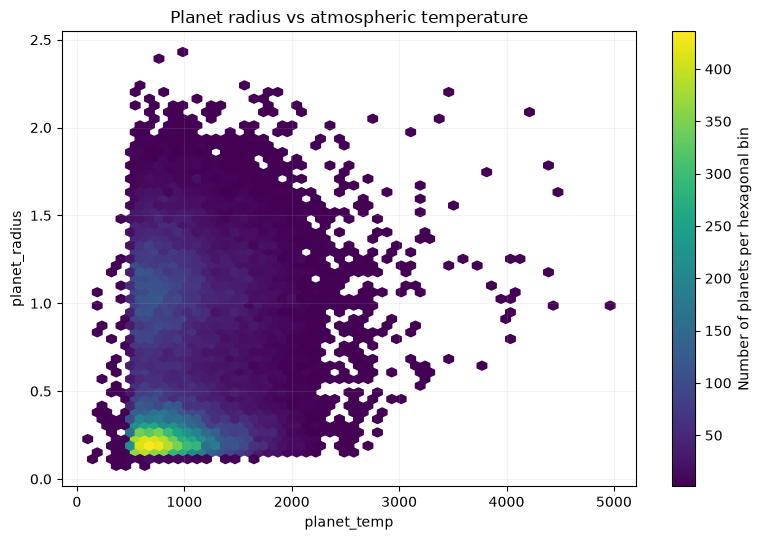

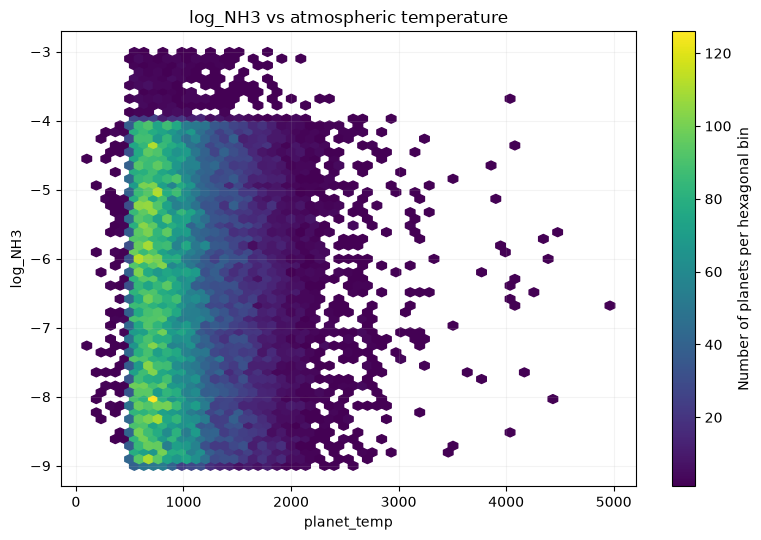

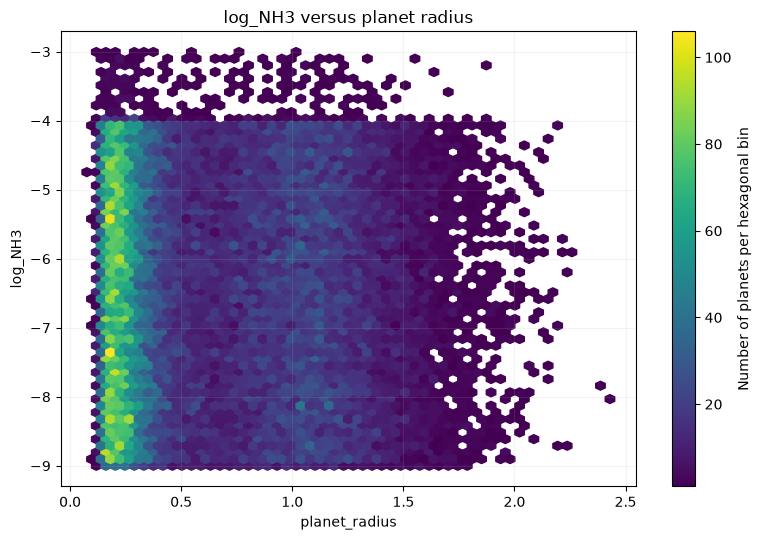

In [12]:
HEXBIN_GRIDSIZE = 55

target_relationships = [
    {"x": "planet_temp",
     "y": "planet_radius",
     "title": "Planet radius vs atmospheric temperature"
     },

     {"x": "planet_temp",
      "y": "log_NH3",
      "title": "log_NH3 vs atmospheric temperature"
      },
      {
        "x": "planet_radius",
        "y": "log_NH3",
        "title": "log_NH3 versus planet radius",
    },
]

for relationship in target_relationships:
    x_name = relationship["x"]
    y_name = relationship["y"]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    hexbin = ax.hexbin(
        target_only[x_name],
        target_only[y_name],
        gridsize=HEXBIN_GRIDSIZE,
        mincnt=1,
        cmap="viridis",
    )

    colour_bar = fig.colorbar(hexbin, ax=ax)
    colour_bar.set_label("Number of planets per hexagonal bin")

    ax.set_title(relationship["title"])
    ax.set_xlabel(f"{x_name}")
    ax.set_ylabel(f"{y_name}")
    ax.grid(alpha=0.15)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

### **Analysis of the radius and temperature distributions**

The `planet_radius` distribution is not unimodal. It contains a strong
concentration of smaller radius planets and a second broad concentration at
larger values. The quartiles reflect this structure: the median is approximately
0.492, whereas the 75th percentile is approximately 1.038. This notebook does
not establish whether these concentrations correspond to distinct physical
planet populations or to the simulator's sampling design, so no physical
interpretation can be determined yet. We will need to discuss this with people who have the domain knowledge or knowledge of the simulator sampling process.

The `planet_temp` distribution is strongly right-skewed. Of the 41,423
labelled planets, 867 (2.093%) have temperatures above 2000, 57 (0.138%) are
above 3000 and only 14 (0.034%) are above 4000. The maximum temperature is
therefore not representative of the bulk of the dataset. Later evaluation
should include a high-temperature subgroup analysis/test, as overall coverage
could hide weak performance in this sparse region.

### **Analysis of the molecular-abundance distributions**

The values for `log_H2O`, `log_CO2`, `log_CO` and `log_CH4` are
approximately uniformly distributed over bounded intervals in logarithmic
space.

The `log_NH3` distribution differs from the other abundance targets. There are
41,042 planets (99.081%) with `log_NH3 <= -4` and only 381 (0.919%) above -4.
Fixed-width bins below -4 contain approximately 2,000 planets each, whereas
bins above -4 contain only around 85–109 planets. This highlights a sharp
reduction in sampling density rather than a 'thinning' tail.

### **Analysis of relationships among targets**

Both the Pearson and Spearman correlation matrices contain values very close
to zero for every pair combination of targets. The largest absolute Spearman coefficient
is only approximately 0.0105. There is therefore no meaningful
global linear or monotonic correlation among the seven simulator parameters.

This could be expected with the targets being sampled independently.
However, almost zero correlation does not imply that their marginal
distributions are simplistic, which we see with `planet_radius` being multimodal, and `planet_temp`
is strongly right-skewed. `log_NH3` contains a small sparse region above -4.

These correlations also do not measure how well spectra or auxiliary metadata
predict each target. They only describe relationships among the simulator parameters

### **Implications for conformal evaluation**

The target distributions contain rare regions that may be hidden by aggregate
coverage. In particular, approximately 2.1% of the planets have `planet_temp > 2000`, while approximately 0.9% have
`log_NH3 > -4`.

Overall marginal coverage will still be the primary conformal metric, but later
evaluation should also explore descriptive coverage and interval width for
these subgroups when their held-out sample counts are sufficient/large enough. More extreme
temperature thresholds, such as 3000 or 4000, contain too few examples to
support stable standalone coverage estimates after the data are split. **What do we do with this?**

# **2. Auxiliary metadata exploration**

These auxiliary tables/data contain stellar and planetary information associated with each spectrum. There is one table for the labelled training and another for the unlabelled Ariel challenge.

Before we can explore the distributions, both these tables must be checked for:

- The expected source columns
- Valid and unique `planet_ID` values
- Compatible training and challenge data formats



In [13]:
TRAINING_METADATA_PATH = (
    PROJECT_ROOT
    / "FullDataset"
    / "TrainingData"
    / "AuxillaryTable.csv"
)
CHALLENGE_METADATA_PATH = (
    PROJECT_ROOT
    / "FullDataset"
    / "TestData"
    / "AuxillaryTable.csv"
)

EXPECTED_AUXILIARY_COLUMNS = [
    "planet_ID",
    "star_distance",
    "star_mass_kg",
    "star_radius_m",
    "star_temperature",
    "planet_mass_kg",
    "planet_orbital_period",
    "planet_distance",
    "planet_surface_gravity",
]

def require_file(path: Path, source_name: str) -> None:
    """Fail if a required source file is not located"""

    if not path.is_file():
        raise FileNotFoundError(f"{source_name} was not found at: {path}")


def validate_metadata_identifiers(table: pd.DataFrame, source_name: str) -> None:
    """Validate the planet identifier column in one metadata table."""

    if "planet_ID" not in table.columns:
        raise ValueError(f"{source_name} does not contain a planet_ID column.")

    missing_count = int(table["planet_ID"].isna().sum())

    if missing_count > 0:
        raise ValueError(f"{source_name} contains {missing_count} missing planet IDs")

    blank_id_mask = (table["planet_ID"].astype(str).str.strip().eq(""))
    blank_count = int(blank_id_mask.sum())

    if blank_count > 0:
        raise ValueError(f"{source_name} contains {blank_count} blank planet IDs")

    duplicate_mask = table["planet_ID"].duplicated(keep=False)
    duplicate_count = int(duplicate_mask.sum())

    if duplicate_count > 0:
        duplicate_examples = (table.loc[duplicate_mask, "planet_ID"].astype(str).unique().tolist()[:5])

        raise ValueError(f"{source_name} contains {duplicate_count} rows with "
                         f"duplicate planet IDs. Examples: {duplicate_examples}")

require_file(TRAINING_METADATA_PATH, "Labelled training auxiliary table")
require_file(CHALLENGE_METADATA_PATH, "Unlabelled challenge auxiliary table")

training_metadata = pd.read_csv(TRAINING_METADATA_PATH)
challenge_metadata = pd.read_csv(CHALLENGE_METADATA_PATH)

for source_name, table in{"labelled training metadata": training_metadata,
                          "unlabelled challenge metadata": challenge_metadata}.items():
    missing_columns = [column for column in EXPECTED_AUXILIARY_COLUMNS
                       if column not in table.columns]

    if missing_columns:
        raise ValueError(f"{source_name} is missing required columns: "
                         f"{missing_columns}")

    validate_metadata_identifiers(table, source_name)

all_meta_data_columns = list(dict.fromkeys(training_metadata.columns.tolist() + 
                                           challenge_metadata.columns.tolist()))

metadata_schema = pd.DataFrame({"training_dtype": (training_metadata.dtypes.astype(str).reindex(all_meta_data_columns)),
                                "challenge_dtype": (challenge_metadata.dtypes.astype(str).reindex(all_meta_data_columns)),
                                "present_in_training": [column in training_metadata.columns
                                                        for column in all_meta_data_columns],
                                "present_in_challenge": [column in challenge_metadata.columns
                                                         for column in all_meta_data_columns],
                                },
                                index=all_meta_data_columns)

same_column_order = (training_metadata.columns.tolist() == challenge_metadata.columns.tolist())
same_dtypes = (training_metadata.dtypes.astype(str).to_dict() == challenge_metadata.dtypes.astype(str).to_dict())

print("Training metadata path:", TRAINING_METADATA_PATH)
print("Challenge metadata path:", CHALLENGE_METADATA_PATH)

print("\nTraining metadata shape:", training_metadata.shape)
print("Challenge metadata shape:", challenge_metadata.shape)

print("\nTraining planet IDs:", training_metadata["planet_ID"].nunique())
print("Challenge planet IDs:", challenge_metadata["planet_ID"].nunique())

print("\nSame column names and order:", same_column_order)
print("Same dtypes:", same_dtypes)

print("\nMetadata schema:")
display(metadata_schema)

if not same_column_order:
    raise ValueError("Training and challenge metadata columns do not have the same names and order")

if not same_dtypes:
    raise ValueError("Training and challenge metadata columns do not have the same dtypes")

print("\nMetadata source data format checks passed")

Training metadata path: /home/ajf23/Documents/Coding new/University stuff/ADC2023/ADC2023-conformal-prediction/FullDataset/TrainingData/AuxillaryTable.csv
Challenge metadata path: /home/ajf23/Documents/Coding new/University stuff/ADC2023/ADC2023-conformal-prediction/FullDataset/TestData/AuxillaryTable.csv

Training metadata shape: (41423, 9)
Challenge metadata shape: (685, 9)

Training planet IDs: 41423
Challenge planet IDs: 685

Same column names and order: True
Same dtypes: True

Metadata schema:


,training_dtype,challenge_dtype,present_in_training,present_in_challenge
planet_ID,str,str,True,True
star_distance,float64,float64,True,True
star_mass_kg,float64,float64,True,True
star_radius_m,float64,float64,True,True
star_temperature,float64,float64,True,True
planet_mass_kg,float64,float64,True,True
planet_orbital_period,float64,float64,True,True
planet_distance,float64,float64,True,True
planet_surface_gravity,float64,float64,True,True



Metadata source data format checks passed


This is important as the preprocessing pipeline will apply the same feature definition to the labelled and challenge observations.

# **3. Metadata distributions**

### **3.1 Summary of candidate metadata predictors**

The auxiliary table contains 8 variables that are potential inputs. We inspect their distributions in their original form **before** applying any transformations or feature selection/engineering.

We check numerical validity, uniqueness, spread and range of the data (only the labelled training metadata).

In [14]:
METADATA_FEATURES = [
    "star_distance",
    "star_mass_kg",
    "star_radius_m",
    "star_temperature",
    "planet_mass_kg",
    "planet_orbital_period",
    "planet_distance",
    "planet_surface_gravity"
]

missing_metadata_features = [feature for feature in METADATA_FEATURES
                             if feature not in training_metadata.columns]

if missing_metadata_features:
    raise ValueError("The labelled training metadata is missing required features: "
                     f"{missing_metadata_features}")

non_numeric_features = [feature for feature in METADATA_FEATURES
                        if not pd.api.types.is_numeric_dtype(training_metadata[feature])]

if non_numeric_features:
    raise TypeError("The following metadata features are not stored as numeric: "
                    f"columns {non_numeric_features}")

metadata_only = training_metadata.loc[:, METADATA_FEATURES]
print("Metadata feature shape:", metadata_only.shape)
print("Ordered metadata features:", metadata_only.columns.tolist())
print("All the selected metadata columns have numeric dtypes.")

Metadata feature shape: (41423, 8)
Ordered metadata features: ['star_distance', 'star_mass_kg', 'star_radius_m', 'star_temperature', 'planet_mass_kg', 'planet_orbital_period', 'planet_distance', 'planet_surface_gravity']
All the selected metadata columns have numeric dtypes.


In [15]:
metadata_values = metadata_only.to_numpy(dtype = np.float64)

metadata_missing_counts = metadata_only.isna().sum()

metadata_non_finite_counts = pd.Series(
    (~np.isfinite(metadata_values)).sum(axis=0),
    index=METADATA_FEATURES, name = "non_finite_count")

metadata_summary = (metadata_only.describe(percentiles=[0.25, 0.50, 0.75]).T.rename(
    columns = {"min": "minimum",
               "25%": "25th_percentile",
               "50%": "median",
               "75%": "75th_percentile",
               "max": "maximum",
               "std": "standard_deviation"
                }
        )
)

metadata_summary.insert(1, "missing_count", metadata_missing_counts)

metadata_summary.insert(2, "non_finite_count", metadata_non_finite_counts)

metadata_summary.insert(3, "unique_count",  metadata_only.nunique(dropna=True))

metadata_summary = metadata_summary.loc[:,
                                        [
                                            "count",
                                            "missing_count",
                                            "non_finite_count",
                                            "unique_count",
                                            "minimum",
                                            "25th_percentile",
                                            "median",
                                            "75th_percentile",
                                            "maximum",
                                            "mean",
                                            "standard_deviation"
                                        ]
                                    ]

print("Labelled training metadata summary: ")
display(metadata_summary)

Labelled training metadata summary: 


,count,missing_count,non_finite_count,unique_count,minimum,25th_percentile,median,75th_percentile,maximum,mean,standard_deviation
star_distance,41423.0,0,0,3030,6.531270e+00,3.188100e+02,6.394110e+02,1.002120e+03,7.470050e+03,7.123978e+02,4.911711e+02
star_mass_kg,41423.0,0,0,1018,3.181456e+29,1.729917e+30,1.948642e+30,2.187251e+30,6.193738e+30,1.991245e+30,4.604279e+29
star_radius_m,41423.0,0,0,578,1.391400e+08,5.843880e+08,6.957000e+08,8.765820e+08,4.723803e+09,7.642578e+08,2.983267e+08
star_temperature,41423.0,0,0,1910,3.050000e+03,5.306000e+03,5.695000e+03,5.991000e+03,1.017000e+04,5.608154e+03,6.215288e+02
planet_mass_kg,41423.0,0,0,37684,6.168095e+24,4.688850e+25,1.457616e+26,5.780954e+26,2.732941e+29,7.471938e+26,3.149388e+27
planet_orbital_period,41423.0,0,0,3540,2.241950e-01,4.317680e+00,9.289710e+00,1.864358e+01,1.047836e+03,1.527895e+01,2.236684e+01
planet_distance,41423.0,0,0,3545,6.221077e-03,5.213082e-02,8.442447e-02,1.354756e-01,2.025430e+00,1.079276e-01,8.411078e-02
planet_surface_gravity,41423.0,0,0,37684,8.055090e-02,6.192643e+00,8.630901e+00,1.217426e+01,3.569025e+03,1.362197e+01,3.882752e+01


In [16]:
total_missing = int(metadata_missing_counts.sum())
total_non_finite = int(metadata_non_finite_counts.sum())

print("Total missing values:", total_missing)
print("Total non-finite values:", total_non_finite)

if total_missing > 0 or total_non_finite > 0:
    print("NOTE: Invalid metadata values in the dataset")
else:
    print("All metadata values are included and finite. We have no NaNs or +/- inf")

Total missing values: 0
Total non-finite values: 0
All metadata values are included and finite. We have no NaNs or +/- inf


### **3.2 Distributions of candidate metadata predictors**

Each predictor is plotted separately as the variables have different unit and scales.

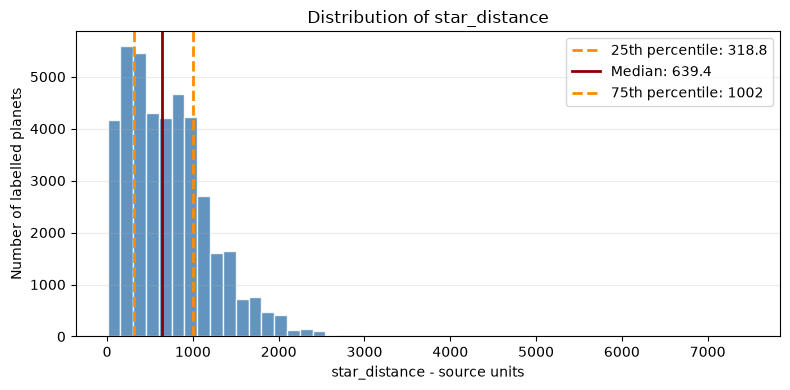

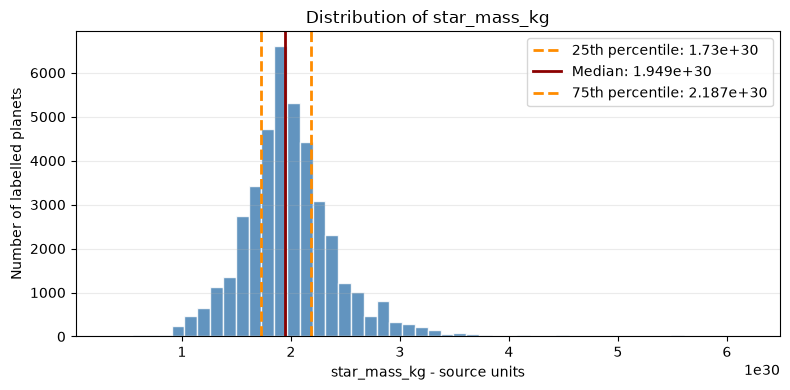

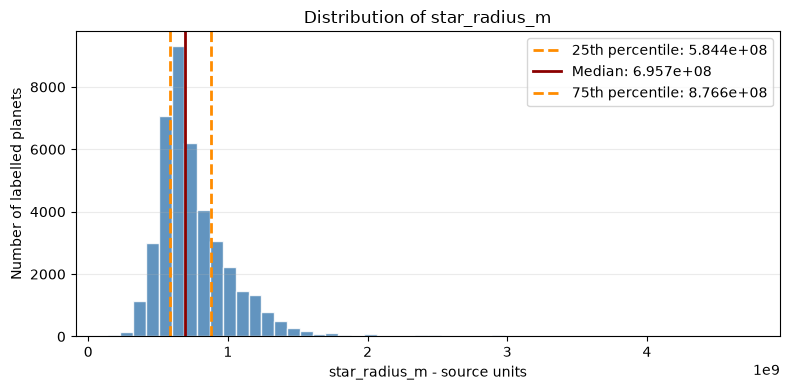

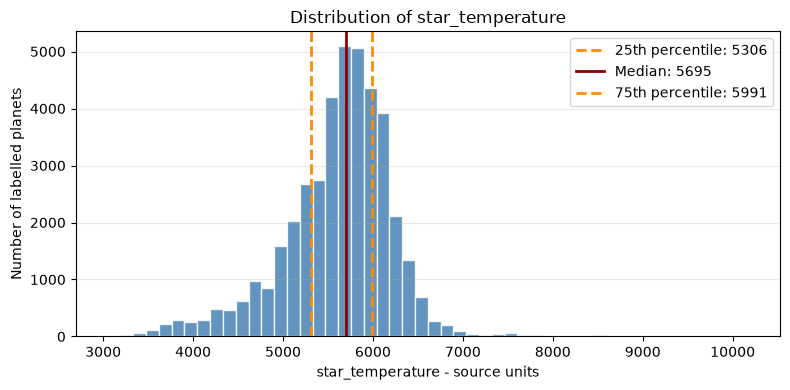

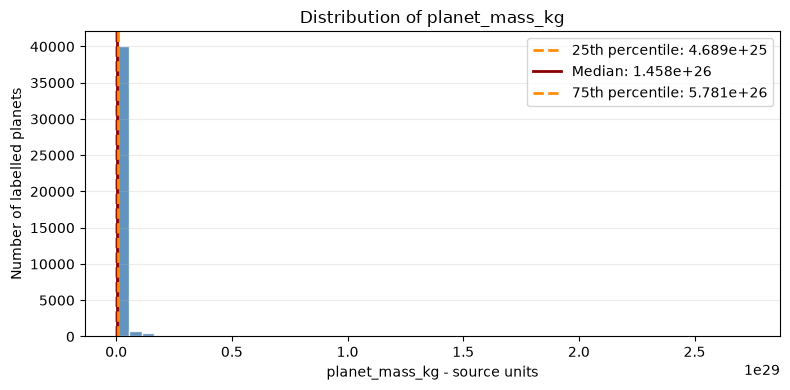

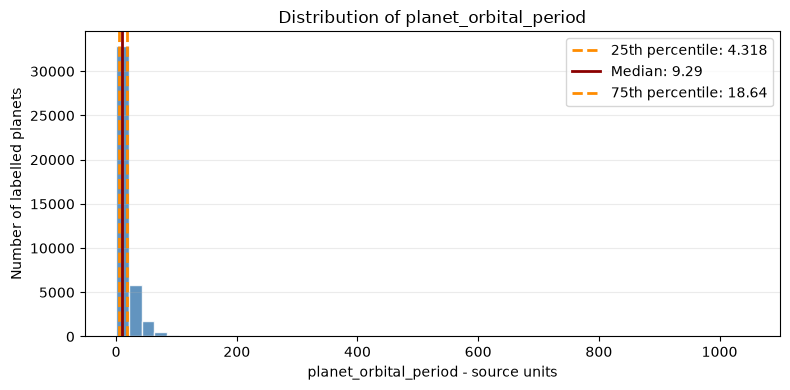

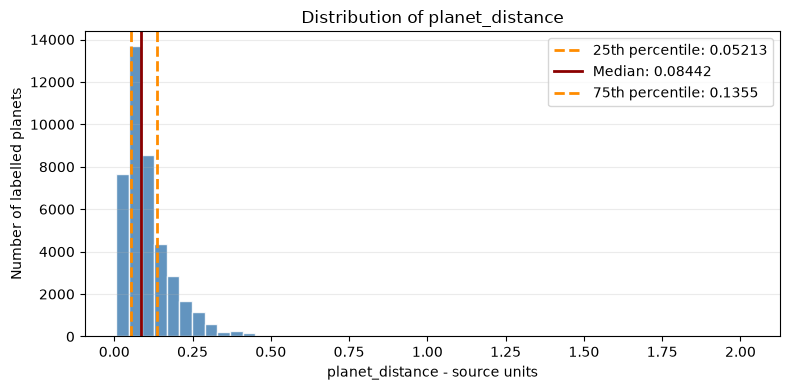

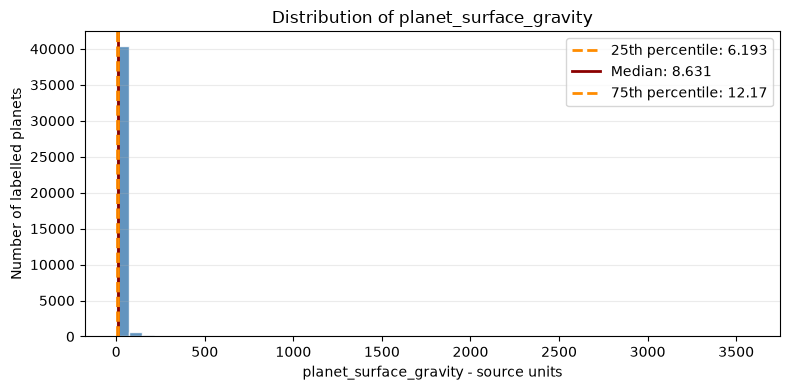

In [17]:
METADATA_HISTOGRAM_BINS = 50

for feature_name in METADATA_FEATURES:
    feature_values = metadata_only[feature_name]

    q25 = feature_values.quantile(0.25)
    median = feature_values.quantile(0.50)
    q75 = feature_values.quantile(0.75)

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.hist(feature_values,
             bins=METADATA_HISTOGRAM_BINS,
             color="steelblue",
             edgecolor="white",
             alpha=0.85)

    ax.axvline(q25,
            color="darkorange",
            linestyle="--",
            linewidth=2,
            label=f"25th percentile: {q25:.4g}")
        

    ax.axvline(median,
            color="darkred",
            linestyle="-",
            linewidth=2,
            label=f"Median: {median:.4g}")

    ax.axvline(q75,
            color="darkorange",
            linestyle="--",
            linewidth=2,
            label=f"75th percentile: {q75:.4g}")

    ax.set_title(f"Distribution of {feature_name}")
    ax.set_xlabel(f"{feature_name} - source units")
    ax.set_ylabel("Number of labelled planets")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    plt.show()
    plt.close(fig)
    

The raw scale histograms for '`planet_mass_kg`, `planet_orbital_period` and `planet_surface_gravity` are visibly compressed by their ranges and long tails.

Below is the logarithmic scale instead compared with the raw scale:

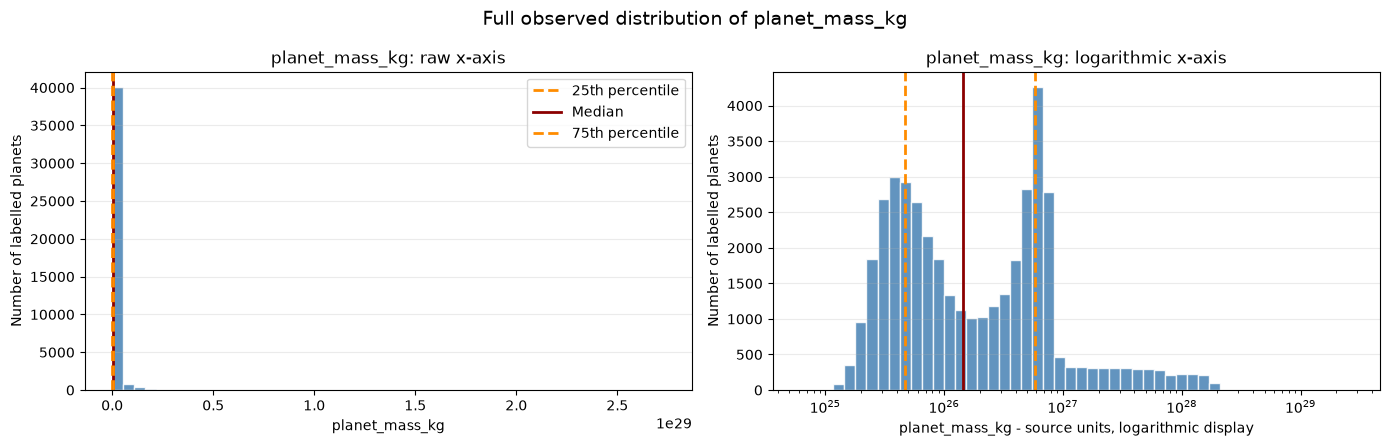

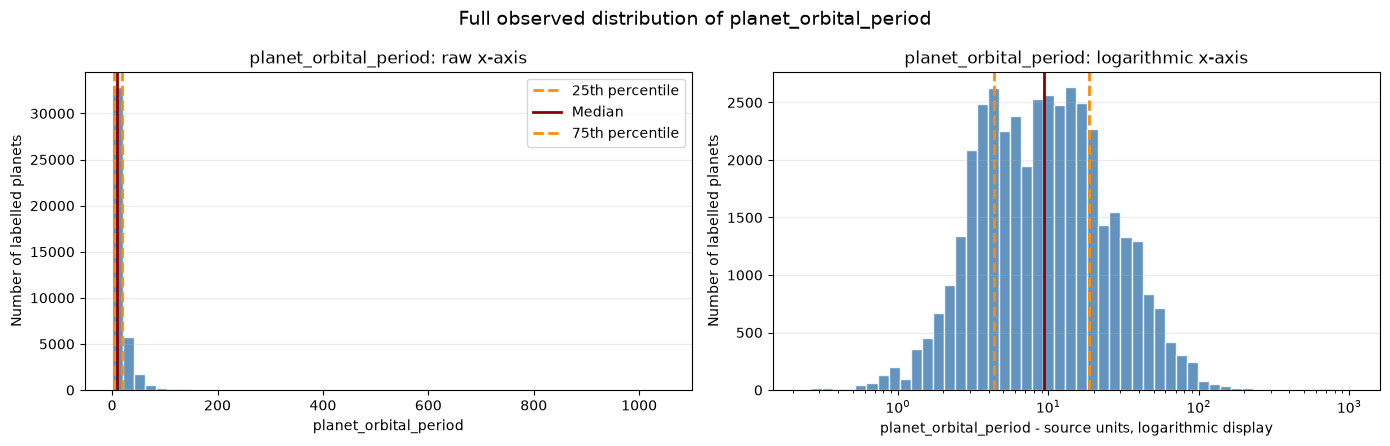

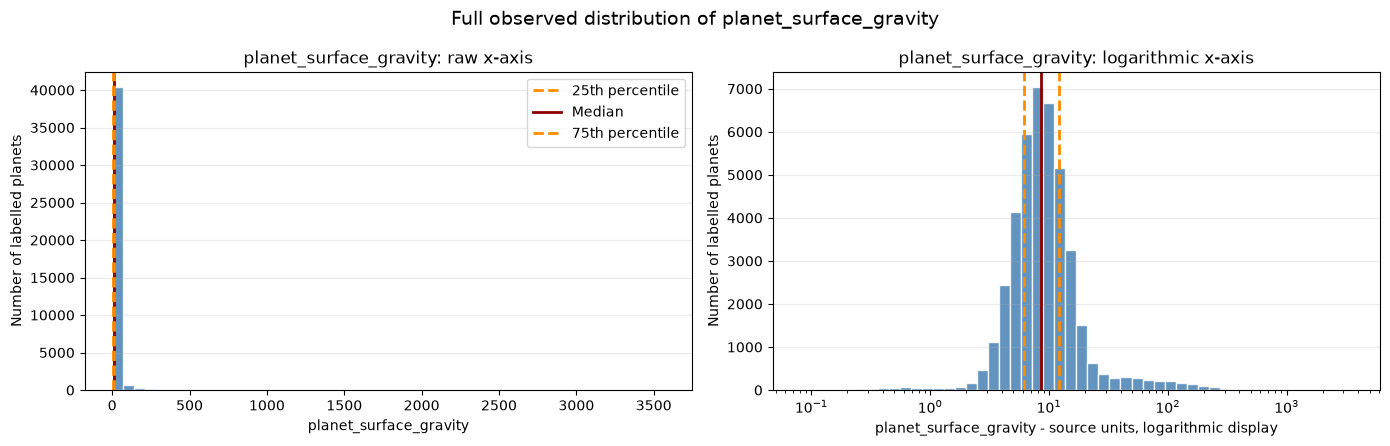

In [18]:
SKEWED_METADATA_FEATURES = [
    "planet_mass_kg",
    "planet_orbital_period",
    "planet_surface_gravity",
]


LOG_VIEW_BINS = 50

for feature_name in SKEWED_METADATA_FEATURES:
    feature_values = metadata_only[feature_name]

    if (feature_values <= 0).any():
        non_positive_count = int((feature_values <= 0).sum())

        raise ValueError(f"{feature_name} contains {non_positive_count} values that "
            "are zero or negative, so a logarithmic x-axis is not valid.")

    q25 = feature_values.quantile(0.25)
    median = feature_values.quantile(0.50)
    q75 = feature_values.quantile(0.75)

    log_bin_edges = np.geomspace(
        feature_values.min(),
        feature_values.max(),
        LOG_VIEW_BINS + 1
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 4.5)
    )

    raw_axis, log_axis = axes

    raw_axis.hist(
        feature_values,
        bins=LOG_VIEW_BINS,
        color="steelblue",
        edgecolor="white",
        alpha=0.85
    )

    log_axis.hist(
        feature_values,
        bins=log_bin_edges,
        color="steelblue",
        edgecolor="white",
        alpha=0.85
    )
    log_axis.set_xscale("log")

    for axis in axes:
        axis.axvline(
            q25,
            color="darkorange",
            linestyle="--",
            linewidth=2,
            label="25th percentile"
        )
        axis.axvline(
            median,
            color="darkred",
            linestyle="-",
            linewidth=2,
            label="Median"
        )
        axis.axvline(
            q75,
            color="darkorange",
            linestyle="--",
            linewidth=2,
            label="75th percentile"
        )

        axis.set_ylabel("Number of labelled planets")
        axis.grid(axis="y", alpha=0.25)

    raw_axis.set_title(f"{feature_name}: raw x-axis")
    raw_axis.set_xlabel(f"{feature_name}")
    raw_axis.legend()

    log_axis.set_title(f"{feature_name}: logarithmic x-axis")
    log_axis.set_xlabel(f"{feature_name} - source units, logarithmic display")

    fig.suptitle(f"Full observed distribution of {feature_name}", fontsize=14)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## **4. Relationships between auxiliary metadata and targets**

We investigate the statistical relationships between the 8 metadata predictors (pre any feature engineering) and the 7 targets.

The labelled auxiliary and target data tables are joined using `planet_ID`. We are not utilising row order, as highlighted in the `01_data_audit.ipynb` file, the data tables could contain the same planets but in different orders.

We use Spearman rank correlation again for summarising any monotonic association and capturing relationships that increase/decrease without being linear.

**NOTE:** Correlation does not establish causation, identify any physics, or justify the automatic removing or selection of a feature.

In [19]:
EXPECTED_LABEL_COUNT = 41_423

ANALYSIS_COLUMNS = [
    "planet_ID",
    *METADATA_FEATURES,
    *TARGET_COLUMNS
]

metadata_for_merge = training_metadata.loc[:, ["planet_ID", *METADATA_FEATURES]].copy()

targets_for_merge = targets.loc[:, ["planet_ID", *TARGET_COLUMNS]].copy()

if len(metadata_for_merge) != EXPECTED_LABEL_COUNT:
    raise ValueError("Unexpected number of labelled metadata rows: ",
                     f"expected {EXPECTED_LABEL_COUNT}, ",
                     f"found {len(metadata_for_merge)}")

if len(targets_for_merge) != EXPECTED_LABEL_COUNT:
    raise ValueError("Unexpected number of labelled target rows: ",
                     f"expected {EXPECTED_LABEL_COUNT}, ",
                     f"found {len(targets_for_merge)}")

labelled_analysis = metadata_for_merge.merge(targets_for_merge, on="planet_ID",
                                             how="inner",
                                             validate="one_to_one")

metadata_ids = set(metadata_for_merge["planet_ID"])
target_ids = set(targets["planet_ID"])
merged_ids = set(labelled_analysis["planet_ID"])

lost_metadata_ids = metadata_ids - merged_ids
lost_target_ids = target_ids - merged_ids

if lost_metadata_ids or lost_target_ids:
    raise ValueError("The metadata target merge has lost labelled planets! ",
                     f"Metadata IDs not merged: {len(lost_metadata_ids)} ",
                     f"Target IDs not merged: {len(lost_target_ids)}")

if len(labelled_analysis) != EXPECTED_LABEL_COUNT:
    raise ValueError(
        "The merged labelled analysis table has the wrong row count: "
        f"expected {EXPECTED_LABEL_COUNT}, "
        f"found {len(labelled_analysis)}."
    )

if not labelled_analysis["planet_ID"].is_unique:
    raise ValueError("planet_ID is not unique after the metadata target merge")

missing_analysis_columns = [column for column in ANALYSIS_COLUMNS
                            if column not in labelled_analysis.columns]

if missing_analysis_columns:
    raise ValueError("The merged analysis table is missing the required columns: ",
                     f"{missing_analysis_columns}")

labelled_analysis = labelled_analysis.loc[:, ANALYSIS_COLUMNS]

print("Merged analysis shape: ", labelled_analysis.shape)
print("Unique planet IDs:", labelled_analysis["planet_ID"].nunique())
print("Metadata IDs lost:", len(lost_metadata_ids))
print("Target IDs lost:", len(lost_target_ids))
print("Analysis columns:")
print(labelled_analysis.columns.tolist())

Merged analysis shape:  (41423, 16)
Unique planet IDs: 41423
Metadata IDs lost: 0
Target IDs lost: 0
Analysis columns:
['planet_ID', 'star_distance', 'star_mass_kg', 'star_radius_m', 'star_temperature', 'planet_mass_kg', 'planet_orbital_period', 'planet_distance', 'planet_surface_gravity', 'planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']


In [20]:
labelled_analysis

,planet_ID,star_distance,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,planet_orbital_period,planet_distance,planet_surface_gravity,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,train1,530.7650,1.968526e+30,6.678720e+08,5636.0,3.990923e+26,9.668577,0.088530,16.642039,0.559620,863.394770,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540
1,train2,440.0890,1.948642e+30,7.235280e+08,5449.0,4.977001e+26,4.218028,0.050752,5.197135,1.118308,1201.700465,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658
2,train3,1126.3700,2.147483e+30,7.791840e+08,5675.0,9.686804e+25,2.828042,0.040158,7.871718,0.400881,1556.096477,-7.225472,-6.931472,-3.081975,-8.567854,-5.378472
3,train4,1257.1600,2.048062e+30,7.374420e+08,5849.0,4.486340e+25,3.855604,0.048601,4.894681,0.345974,1268.624884,-7.461157,-5.853334,-3.044711,-5.149378,-3.815568
4,train5,211.5530,2.525281e+30,1.092249e+09,6200.0,2.416329e+26,3.076340,0.044833,5.870151,0.733184,1707.323564,-4.140844,-7.460278,-3.181793,-5.996593,-4.535345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41418,train41419,703.3020,1.988410e+30,7.722270e+08,5821.0,7.125924e+26,5.370647,0.060024,4.544766,1.430950,1167.563319,-7.556565,-7.075889,-4.735715,-7.532563,-7.854443
41419,train41420,72.7998,1.292466e+30,4.035060e+08,4258.0,7.709155e+25,6.342000,0.058089,13.050003,0.277752,649.703932,-7.434332,-7.161510,-5.274940,-4.100312,-3.651804
41420,train41421,1786.4800,1.789569e+30,7.096140e+08,6002.0,2.794853e+25,3.546511,0.043946,19.728779,0.136016,1445.371723,-5.525906,-5.079240,-4.945121,-5.787630,-8.015444
41421,train41422,329.0410,1.849221e+30,6.748290e+08,5519.0,1.400242e+26,22.631964,0.152856,3.649544,0.707851,653.284686,-4.616695,-8.782546,-3.767229,-3.221403,-8.427805


#### **4.2 Calculate the 8x7 Spearman matrix**

The Spearman correlation replaces each variable's values with ranks and then measures the linear correlation between those ranks. It is summarising whether two variables tend to move in the same or opposite direction, even if the relationship is curved rather than linear (useful!).

- +1 indicates strong positive monotonic relationship.
- -1 indicates strong negative monotonic relationship.
- 0 indicates weak monotonic relationship. This does **not** prove independence.

In [21]:
correlation_columns = [*METADATA_FEATURES, *TARGET_COLUMNS]

full_spearman_matrix = labelled_analysis[correlation_columns].corr(method="spearman")

metadata_target_spearman = full_spearman_matrix.loc[METADATA_FEATURES, TARGET_COLUMNS]

if metadata_target_spearman.shape != (8, 7):
    raise ValueError("Unexpected metadata target correlation shape: ",
                     f"{metadata_target_spearman.shape}")

if not np.isfinite(metadata_target_spearman.to_numpy()).all():
    raise ValueError("The Spearman matrix contains non-finite coefficients")

print("Metadata target Spearman matrix shape:", metadata_target_spearman.shape)
display(metadata_target_spearman.round(3))

Metadata target Spearman matrix shape: (8, 7)


,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
star_distance,0.002,-0.049,-0.000,0.004,-0.008,0.004,0.003
star_mass_kg,0.037,0.418,-0.004,0.002,-0.001,-0.003,0.000
star_radius_m,0.045,0.461,-0.004,0.003,0.001,-0.005,-0.001
star_temperature,0.035,0.349,-0.006,0.000,-0.002,-0.004,-0.004
planet_mass_kg,0.942,0.074,0.005,-0.000,-0.002,0.008,-0.003
planet_orbital_period,-0.049,-0.790,-0.006,-0.005,-0.003,0.005,0.001
planet_distance,-0.044,-0.728,-0.006,-0.005,-0.003,0.004,0.001
planet_surface_gravity,-0.403,-0.003,0.005,-0.001,0.007,-0.004,-0.004


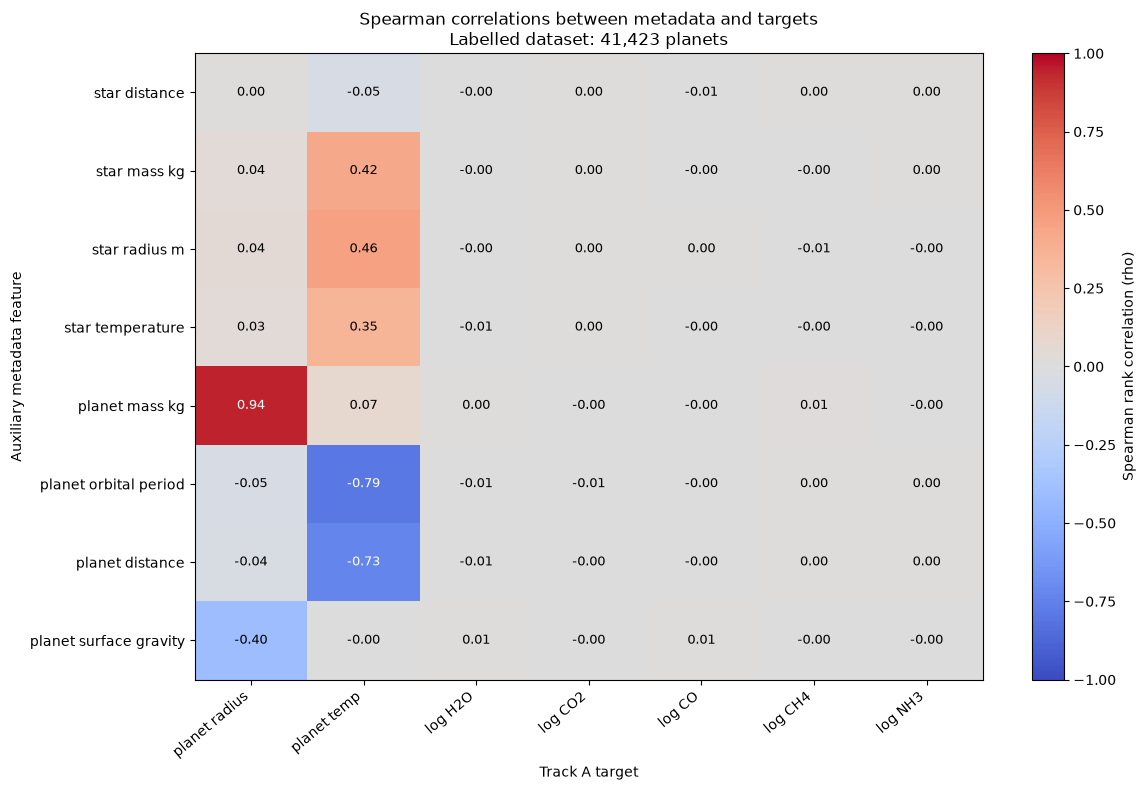

In [22]:
heatmap_values = metadata_target_spearman.to_numpy()

metadata_labels = [feature.replace("_", " ") for feature in METADATA_FEATURES]

target_labels = [target.replace("_", " ") for target in TARGET_COLUMNS]

fig, ax = plt.subplots(figsize=(12, 8))

heatmap = ax.imshow(
    heatmap_values,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

colour_bar = fig.colorbar(heatmap, ax=ax)
colour_bar.set_label("Spearman rank correlation (rho)")

ax.set_xticks(np.arange(len(TARGET_COLUMNS)))
ax.set_xticklabels(target_labels, rotation=40, ha="right")

ax.set_yticks(np.arange(len(METADATA_FEATURES)))
ax.set_yticklabels(metadata_labels)

ax.set_xlabel("Track A target")
ax.set_ylabel("Auxiliary metadata feature")
ax.set_title("Spearman correlations between metadata and targets\n"
             "Labelled dataset: 41,423 planets")

for row_index in range(len(METADATA_FEATURES)):
    for column_index in range(len(TARGET_COLUMNS)):
        rho = heatmap_values[row_index, column_index]

        annotation_colour = ("white" if abs(rho) >= 0.50 else "black")

        ax.text(
            column_index,
            row_index,
            f"{rho:.2f}",
            ha="center",
            va="center",
            color=annotation_colour,
            fontsize=9
        )

fig.tight_layout()
plt.show()
plt.close(fig)

In [23]:
tidy_correlation_rows = []

for metadata_feature in METADATA_FEATURES:
    for target_name in TARGET_COLUMNS:
        rho = float(metadata_target_spearman.loc[metadata_feature, target_name])

        tidy_correlation_rows.append(
            {
                "metadata_feature": metadata_feature,
                "target": target_name,
                "spearman_rho": rho,
                "abs_spearman_rho": abs(rho)
            }
        )

metadata_target_correlations = pd.DataFrame(tidy_correlation_rows)

metadata_target_correlations = (metadata_target_correlations.sort_values(by="abs_spearman_rho", 
                                                                         ascending=False).reset_index(drop=True))

if len(metadata_target_correlations) != 56:
    raise ValueError(
        "Expected 56 metadata-target correlations, "
        f"found {len(metadata_target_correlations)}."
    )

print("Total metadata-target correlations:", len(metadata_target_correlations))

print("\nStrongest 15 associations by absolute Spearman rho:")
display(metadata_target_correlations.head(15))

Total metadata-target correlations: 56

Strongest 15 associations by absolute Spearman rho:


,metadata_feature,target,spearman_rho,abs_spearman_rho
0,planet_mass_kg,planet_radius,0.942498,0.942498
1,planet_orbital_period,planet_temp,-0.789835,0.789835
2,planet_distance,planet_temp,-0.728450,0.728450
3,star_radius_m,planet_temp,0.460769,0.460769
4,star_mass_kg,planet_temp,0.418355,0.418355
5,planet_surface_gravity,planet_radius,-0.402981,0.402981
6,star_temperature,planet_temp,0.348725,0.348725
7,planet_mass_kg,planet_temp,0.073769,0.073769
8,planet_orbital_period,planet_radius,-0.049399,0.049399
9,star_distance,planet_temp,-0.049342,0.049342


### **4.3 Six strongest pairs**

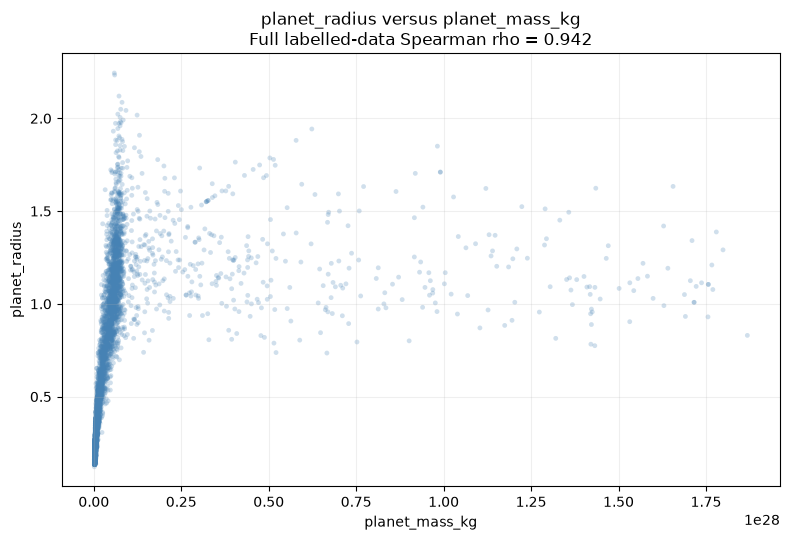

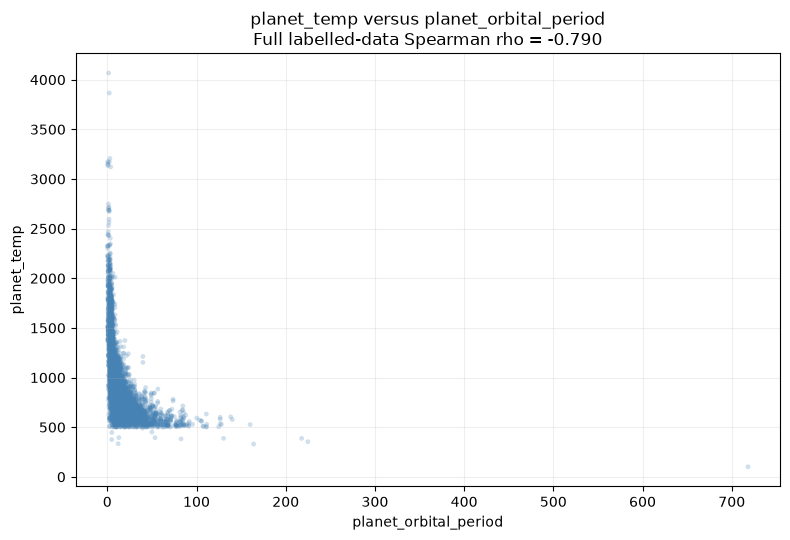

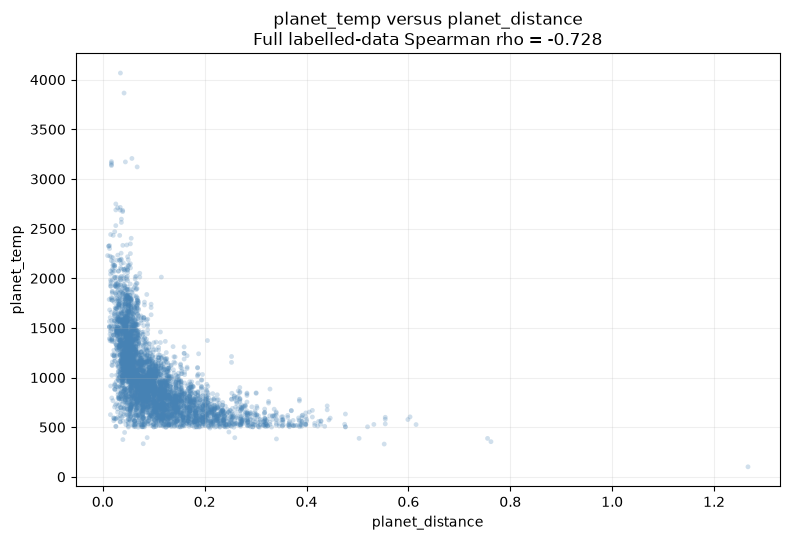

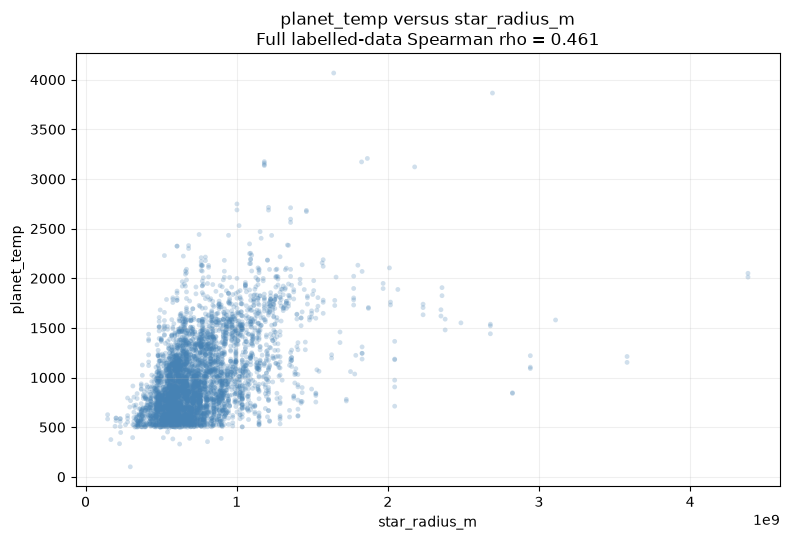

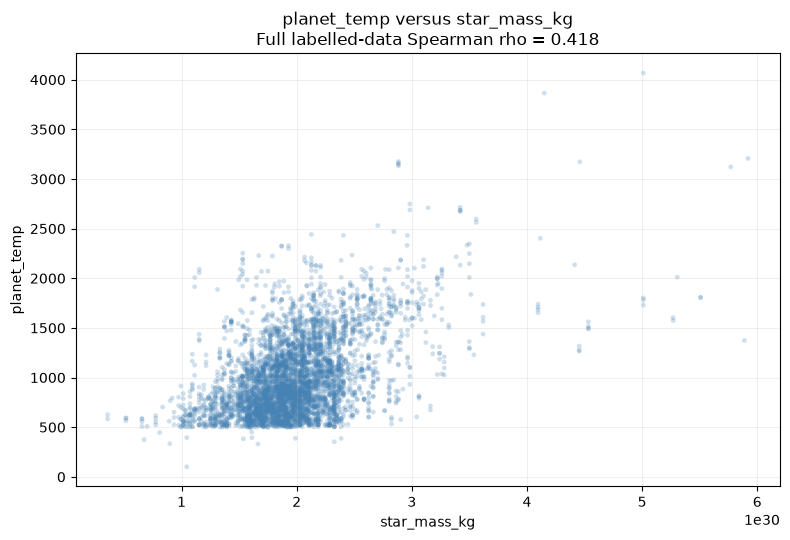

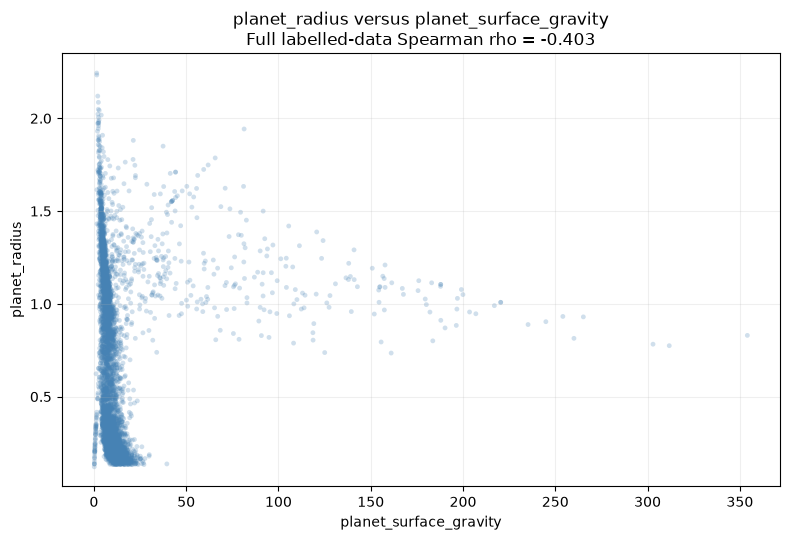

In [24]:
SCATTER_SAMPLE_LIMIT = 5_000
SCATTER_RANDOM_STATE = 42
NUMBER_OF_PAIRS_TO_PLOT = 6

scatter_sample_size = min(SCATTER_SAMPLE_LIMIT, len(labelled_analysis))

scatter_sample = labelled_analysis.sample(
    n=scatter_sample_size,
    random_state=SCATTER_RANDOM_STATE,
    replace=False)

strongest_pairs = metadata_target_correlations.head(NUMBER_OF_PAIRS_TO_PLOT).copy()


for pair in strongest_pairs.itertuples(index=False):
    metadata_feature = pair.metadata_feature
    target_name = pair.target
    full_data_rho = pair.spearman_rho

    fig, ax = plt.subplots(figsize=(8, 5.5))

    ax.scatter(scatter_sample[metadata_feature],
            scatter_sample[target_name],
            s=12,
            alpha=0.25,
            color="steelblue",
            edgecolors="none")

    ax.set_xlabel(f"{metadata_feature}")
    ax.set_ylabel(f"{target_name}")
    ax.set_title(f"{target_name} versus {metadata_feature}\n"
        f"Full labelled-data Spearman rho = {full_data_rho:.3f}")
    ax.grid(alpha=0.20)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

#### **4.4 Analysis of results**

1. `planet_radius` vs `planet_mass_kg`:
- As planet mass increases slightly, radius increases rapdily, but the relationship becomes flatter and dispersed at higher masses.
- Very strong positive monotonic relationship.
- `planet_mass_kg` may be an extremely strong predictor of `planet_radius`.

2. `planet_temp` vs `planet_orbital_period`:
- Hottest planets exist compactly in very short orbital periods.
- Longer period planets are concentrated at relatively low temperatures.
- Increasing period narrows the temperature envelope from above.

3. `planet_temp` vs `planet_distance`:
- Hetereoscedastic relationship.
- Small distances allow both cool and hot planets.

4. `planet_temp` vs `star_radius_m`:
- Large amount of scatter.
- As expected, large stellar radius corresponds to higher planet temperatures.

5. `planet_temp` vs `star_mass_kg`:
- Higher star mass associated with higher planet temperature.
- Useful information but not strongly predictive.

6. `planet_radius` vs ` planet_surface_gravity`: 
- In the sparse areas, a lot of the density is between the range of 1 - 1.5, and it is a slightly decreasing slope.
- Nonlinear and heteroscedastic relationship.
- Worth analysing with planet_mass_kg?


## **5. Analysis of the relationship of the metadata variables to planet radius and temperature**

We can see from the results above the correlation of some metadata variables to `planet_temp` and `planet_radius` targets.

We will perform two checks:
1. Whether `planet_mas_kg` and `planet_surface_gravity` can reconstruct `planet_radius`.
2. Whether the metadata variables associated with `planet_temp` are themselves strongly correlated and therefore contain overlapping information.

These checks are done to assess any statistical redundancy in the features.

#### **5.1 Radius reconstruction**

Planet mass and surface gravity are linked through the equation $$R=\sqrt{\frac{GM}{g}}$$

In [37]:
GRAVITATIONAL_CONSTANT_SI = 6.67430e-11

radius_check = labelled_analysis[
    [
        "planet_ID",
        "planet_mass_kg",
        "planet_surface_gravity",
        "planet_radius"
    ]].copy()

required_radius_values = radius_check[
    [
        "planet_mass_kg",
        "planet_surface_gravity",
        "planet_radius"
    ]].to_numpy(dtype=np.float64)


radius_check["derived_physical_radius_m"] = np.sqrt(
    GRAVITATIONAL_CONSTANT_SI * radius_check["planet_mass_kg"] /
    radius_check["planet_surface_gravity"])

radius_check["derived_radius_ratio"] = (radius_check["derived_physical_radius_m"] / radius_check["planet_radius"])

radius_pearson = radius_check[["derived_physical_radius_m", "planet_radius"]].corr(method="pearson").iloc[0,1]

radius_spearman = radius_check[["derived_physical_radius_m", "planet_radius"]].corr(method="spearman").iloc[0,1]

radius_ratio = radius_check["derived_radius_ratio"]

ratio_median = float(radius_ratio.median())
ratio_q01 = float(radius_ratio.quantile(0.01))
ratio_q99 = float(radius_ratio.quantile(0.99))

relative_q01_q99_spread = (ratio_q99 - ratio_q01) / ratio_median

ratio_coeff_var = (radius_ratio.std() / radius_ratio.mean())

radius_ratio_summary = pd.Series(
    {
        "median_ratio": ratio_median,
        "1st_percentile": ratio_q01,
        "99th_percentile": ratio_q99,
        "relative_1st_to_99th_spread": relative_q01_q99_spread,
        "coefficient_of_variation": ratio_coeff_var
    }, name="derived_radius_m / planet_radius")

print(f"Pearson correlation: {radius_pearson:.8f}")
print(f"Spearman correlation: {radius_spearman:.8f}")
print("\nDerived to supplied radius ratio")
display(radius_ratio_summary.to_frame())

Pearson correlation: 0.97915424
Spearman correlation: 0.98162557

Derived to supplied radius ratio


,derived_radius_m / planet_radius
median_ratio,7.148965e+07
1st_percentile,6.480273e+07
99th_percentile,1.662405e+08
relative_1st_to_99th_spread,1.418916e+00
coefficient_of_variation,3.540247e-01


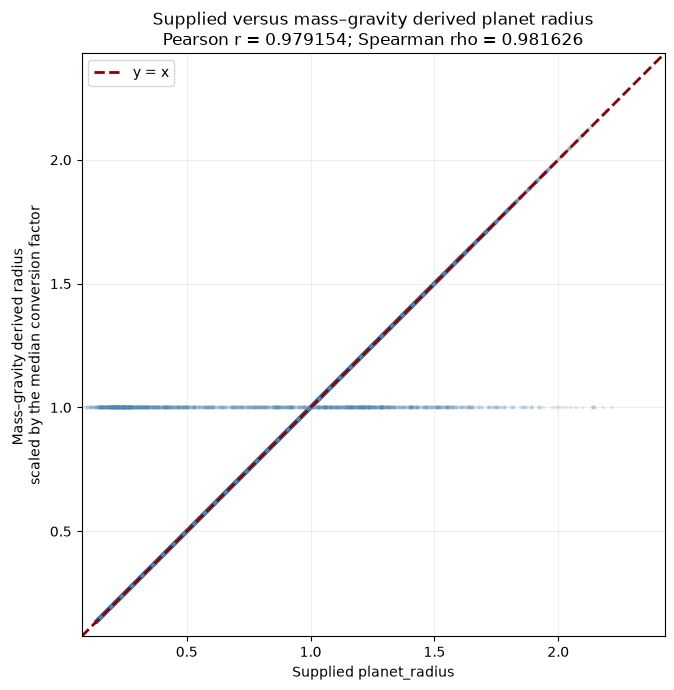

In [38]:
EDA_RADIUS_CONVERSION_FACTOR = ratio_median

radius_check["derived_radius_in_supplied_scale"] = (
    radius_check["derived_physical_radius_m"]
    / EDA_RADIUS_CONVERSION_FACTOR)

plot_minimum = min(
    radius_check["planet_radius"].min(),
    radius_check["derived_radius_in_supplied_scale"].min()
)

plot_maximum = max(
    radius_check["planet_radius"].max(),
    radius_check["derived_radius_in_supplied_scale"].max()
)

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    radius_check["planet_radius"],
    radius_check["derived_radius_in_supplied_scale"],
    s=8,
    alpha=0.15,
    color="steelblue",
    edgecolors="none"
)

ax.plot(
    [plot_minimum, plot_maximum],
    [plot_minimum, plot_maximum],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="y = x"
)

ax.set_xlabel("Supplied planet_radius")
ax.set_ylabel("Mass–gravity derived radius \nscaled by the median conversion factor")
ax.set_title(
    "Supplied versus mass–gravity derived planet radius\n"
    f"Pearson r = {radius_pearson:.6f}; "
    f"Spearman rho = {radius_spearman:.6f}")
ax.set_xlim(plot_minimum, plot_maximum)
ax.set_ylim(plot_minimum, plot_maximum)
ax.set_aspect("equal", adjustable="box")
ax.legend()
ax.grid(alpha=0.20)

fig.tight_layout()
plt.show()
plt.close(fig)

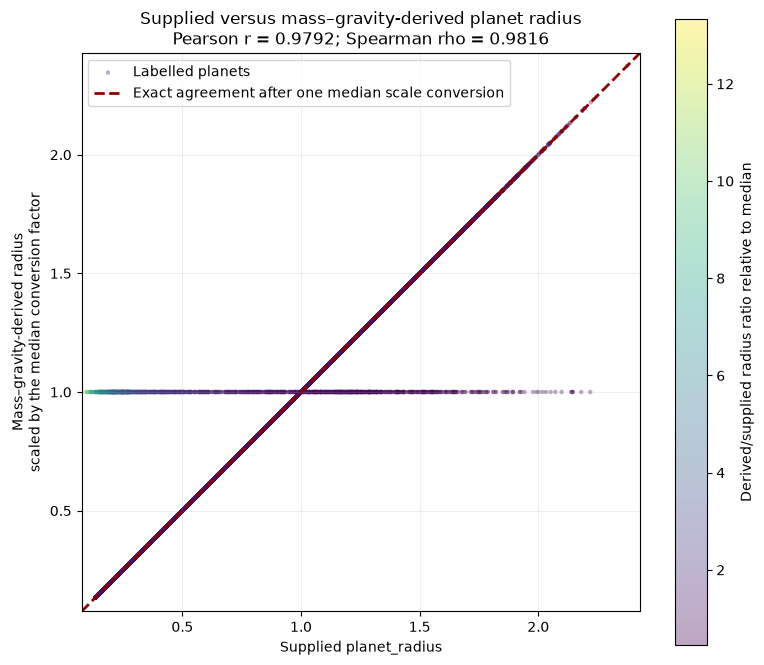

In [41]:
EDA_RADIUS_CONVERSION_FACTOR = ratio_median

radius_check["derived_radius_in_supplied_scale"] = (
    radius_check["derived_physical_radius_m"]
    / EDA_RADIUS_CONVERSION_FACTOR
)

radius_check["ratio_relative_to_median"] = (
    radius_check["derived_radius_ratio"]
    / EDA_RADIUS_CONVERSION_FACTOR
)

plot_minimum = min(
    radius_check["planet_radius"].min(),
    radius_check["derived_radius_in_supplied_scale"].min(),
)

plot_maximum = max(
    radius_check["planet_radius"].max(),
    radius_check["derived_radius_in_supplied_scale"].max(),
)

fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    radius_check["planet_radius"],
    radius_check["derived_radius_in_supplied_scale"],
    c=radius_check["ratio_relative_to_median"],
    cmap="viridis",
    s=10,
    alpha=0.35,
    edgecolors="none",
    label="Labelled planets",
)

equality_line, = ax.plot(
    [plot_minimum, plot_maximum],
    [plot_minimum, plot_maximum],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Exact agreement after one median scale conversion",
)

colour_bar = fig.colorbar(scatter, ax=ax)
colour_bar.set_label(
    "Derived/supplied radius ratio relative to median"
)

ax.set_xlabel("Supplied planet_radius")
ax.set_ylabel(
    "Mass–gravity-derived radius\n"
    "scaled by the median conversion factor"
)

ax.set_title(
    "Supplied versus mass–gravity-derived planet radius\n"
    f"Pearson r = {radius_pearson:.4f}; "
    f"Spearman rho = {radius_spearman:.4f}"
)

ax.set_xlim(plot_minimum, plot_maximum)
ax.set_ylim(plot_minimum, plot_maximum)
ax.set_aspect("equal", adjustable="box")

ax.legend(
    handles=[scatter, equality_line],
    loc="upper left",
)

ax.grid(alpha=0.20)

fig.tight_layout()
plt.show()
plt.close(fig)

- The coloured points are the labelled planets.
- A colour value near 1 means the planet's ratio is close the median ratio.

#### **5.2 Redundancy analysis of temperatured related metadata features**

Oribital period, planet distance and other properties were associated (via Spearman correlation) with `planet_temp`.

The following Spearman matrix now assesses the monotonic relationship among the 5 metadata features.

In [39]:
TEMPERATURE_METADATA = [
    "planet_orbital_period",
    "planet_distance",
    "star_radius_m",
    "star_mass_kg",
    "star_temperature",
]

temp_metadata_spearman = labelled_analysis[TEMPERATURE_METADATA].corr(method="spearman")

print("Spearman correlations among temperature associated metadata features")
display(temp_metadata_spearman)

Spearman correlations among temperature associated metadata features


,planet_orbital_period,planet_distance,star_radius_m,star_mass_kg,star_temperature
planet_orbital_period,1.000000,0.993514,0.088050,0.088262,0.148510
planet_distance,0.993514,1.000000,0.177855,0.186357,0.235010
star_radius_m,0.088050,0.177855,1.000000,0.898786,0.815180
star_mass_kg,0.088262,0.186357,0.898786,1.000000,0.878607
star_temperature,0.148510,0.235010,0.815180,0.878607,1.000000


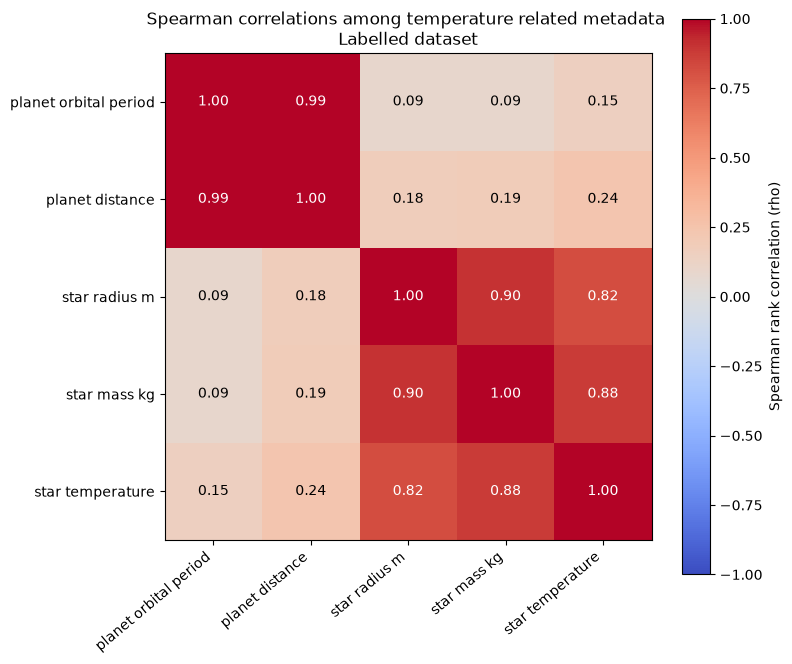

In [40]:
temperature_corr_values = (temp_metadata_spearman.to_numpy())
temp_metadata_labels = [feature.replace("_", " ") for feature in TEMPERATURE_METADATA]

tick_positions = np.arange(len(TEMPERATURE_METADATA))
fig, ax = plt.subplots(figsize = (8,7))

heatmap = ax.imshow(temperature_corr_values, cmap="coolwarm", vmin=-1, vmax=1)
colour_bar = fig.colorbar(heatmap, ax=ax)
colour_bar.set_label("Spearman rank correlation (rho)")

ax.set_xticks(tick_positions)
ax.set_xticklabels(temp_metadata_labels, rotation=40, ha="right")
ax.set_yticks(tick_positions)
ax.set_yticklabels(temp_metadata_labels)
ax.set_title("Spearman correlations among temperature related metadata \nLabelled dataset")

for row_index in range(len(TEMPERATURE_METADATA)):
    for column_index in range(len(TEMPERATURE_METADATA)):
        rho = temperature_corr_values[row_index, column_index]

        text_colour = ("white" if abs(rho) >= 0.50 else "black")
        ax.text(column_index, row_index, f"{rho:.2f}", ha="center", va="center", color=text_colour)

fig.tight_layout()
plt.show()
plt.close(fig)